In [3]:
import glob 
import os
import math
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plot

In [4]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 10  # Default font size for general text
mpl.rcParams['axes.labelsize'] = 11 # Font size for axis labels
mpl.rcParams['xtick.labelsize'] = 9 # Font size for x-axis tick labels
mpl.rcParams['ytick.labelsize'] = 9 # Font size for y-axis tick labels
mpl.rcParams['legend.fontsize'] = 9 # Font size for legend
mpl.rcParams['axes.titlesize'] = 11 # Font size for plot title

In [6]:
def plot_all_simulations(feedback_str, level_ax, cloud_ax, plotstyle):
    
    if feedback_str == '':
        filter_func = lambda x: 'noneg' not in x 
    else:
        filter_func = lambda x: 'noneg' in x
    
    levels_l = np.array(list(filter(filter_func, glob.glob(os.path.join(
        "/home/kd766/quorum-sensing/outputs/subexp",
        f"*/*levels_final.csv")))))
    clouds_l = np.array(list(filter(filter_func, glob.glob(os.path.join(
        "/home/kd766/quorum-sensing/outputs/subexp",
        f"*/*clouds_final.csv")))))
    
    n_trials = len(levels_l)
    print(f"Total # trials: {n_trials}")
    
    density_str_l = []
    # infer all densities and pre-order them into a list.
    for idx, (level_file) in enumerate(levels_l):
        fname = os.path.basename(level_file)
        parts = fname.split('_')
        density = float(parts[3].split('-')[-1])
        density_str = str(round(density, 4))
        density_str_l.append(density_str)
    
    files_sorted_order_idx = np.argsort(density_str_l)
    density_d = dict()
    level_means_d = dict()
    cloud_means_d = dict()
    for idx, (cloud_file, level_file) in enumerate(zip(
        clouds_l[files_sorted_order_idx], levels_l[files_sorted_order_idx])):
    
        fname = os.path.basename(level_file)
        parts = fname.split('_')
        density = float(parts[3].split('-')[-1])
        density_str = str(round(density, 4))
    
        cloud = pd.read_csv(cloud_file, header=None).to_numpy()
        levels = pd.read_csv(level_file, header=None).to_numpy()
        n_cells = np.sum(levels!=0)
    
        cloud_means_d[density_str] = cloud_means_d.get(density_str, []) + [np.sum(cloud)/n_cells]
        level_means_d[density_str] = level_means_d.get(density_str, []) + [np.sum(levels)/n_cells]
        density_d[density_str] = density

    def plot_pts(ax, val_d, ylabel):
        trend_points_l = []
        for density_str in val_d.keys():
            # compute stats.
            trials_mean = np.mean(val_d[density_str])
            trials_std = np.std(val_d[density_str])
            # plot centrality measures.
            ax.errorbar(density_d[density_str], trials_mean, yerr=trials_std, ecolor='red', capsize=5, elinewidth=2)
            # plot all pts.
            mean_signal_mean = np.mean(val_d[density_str])
            trend_points_l.append((density_d[density_str], mean_signal_mean))
            # plot each data point.
            # for signal_mean in level_means_d[density_str]:
            #     level_ax.scatter(density_d[density_str], signal_mean, s=2, c='blue', marker='x')
        ax.plot(*list(zip(*trend_points_l)), plotstyle, ms=5, linewidth=1)
        ax.set_title(('With IL-10 negative feedback' if not feedback_str else 'Without IL-10 negative feedback'))
        ax.set_xlabel("Cell Seeding Density")
        ax.set_ylabel(ylabel)
    
    # plot trends.
    plot_pts(level_ax, level_means_d, "Global Mean TNF Secretion (a.u.)")
    plot_pts(cloud_ax, cloud_means_d, "Global Mean Cloud Intensity (a.u.)")

Total # trials: 152
Total # trials: 106


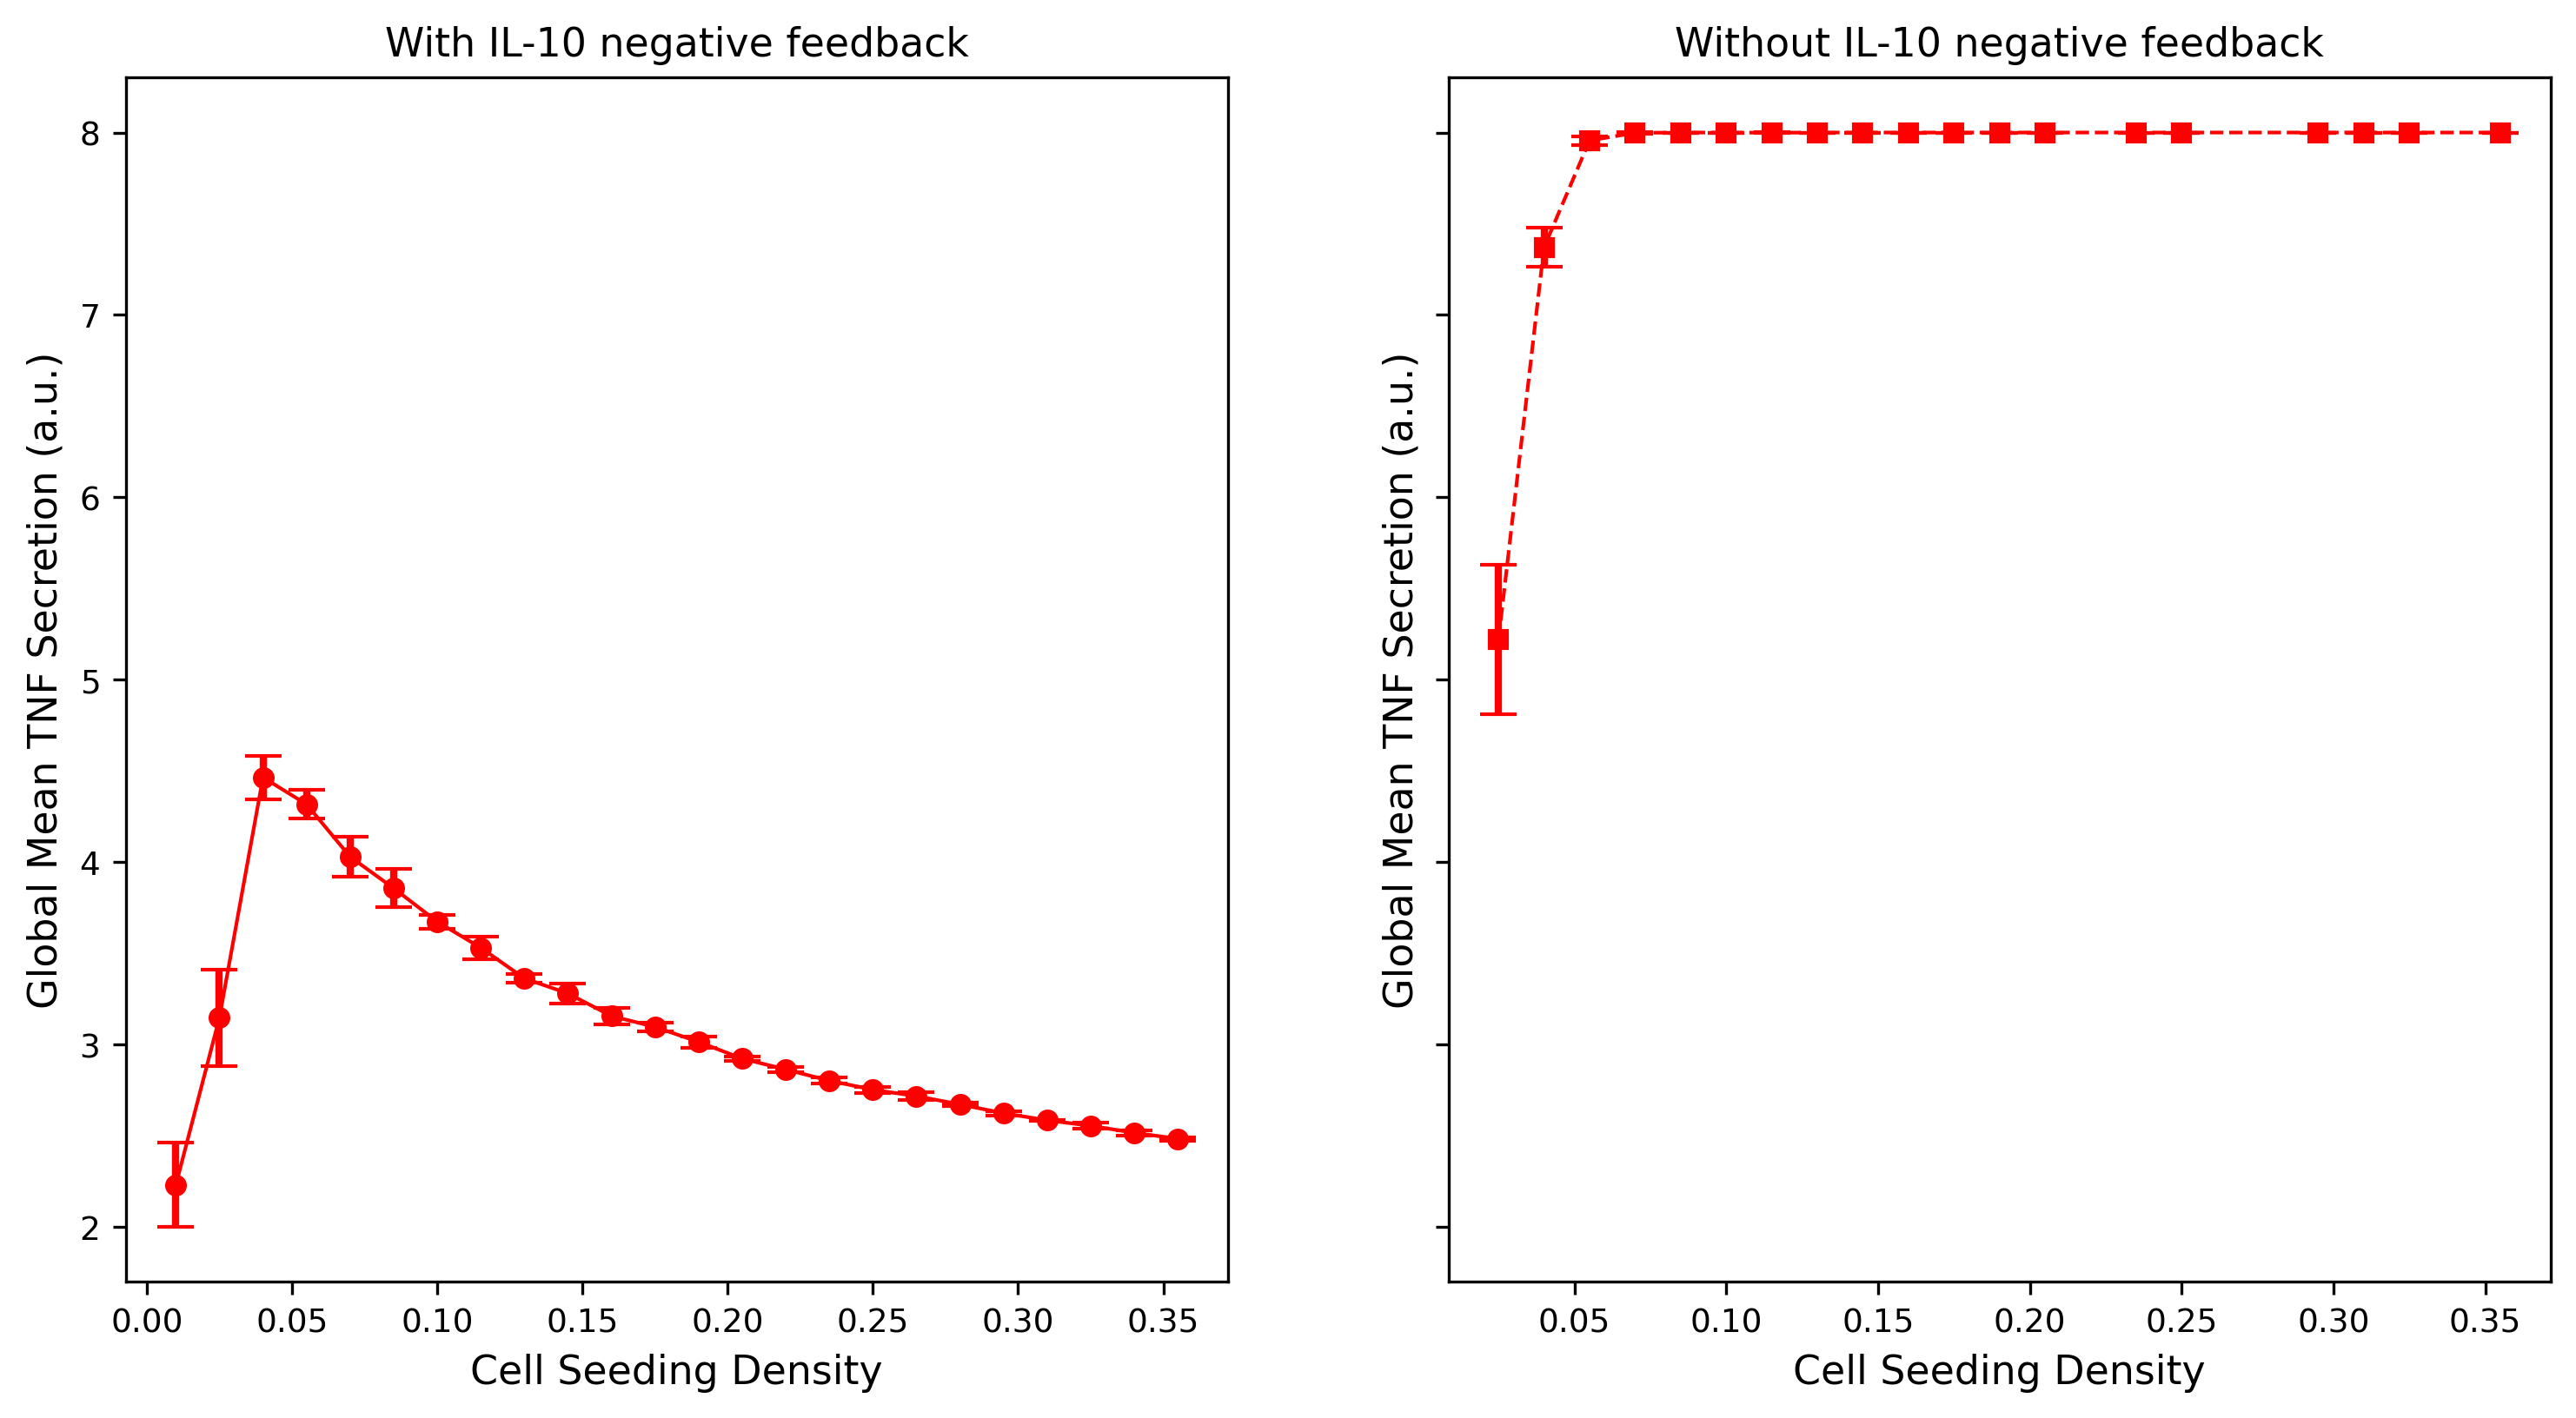

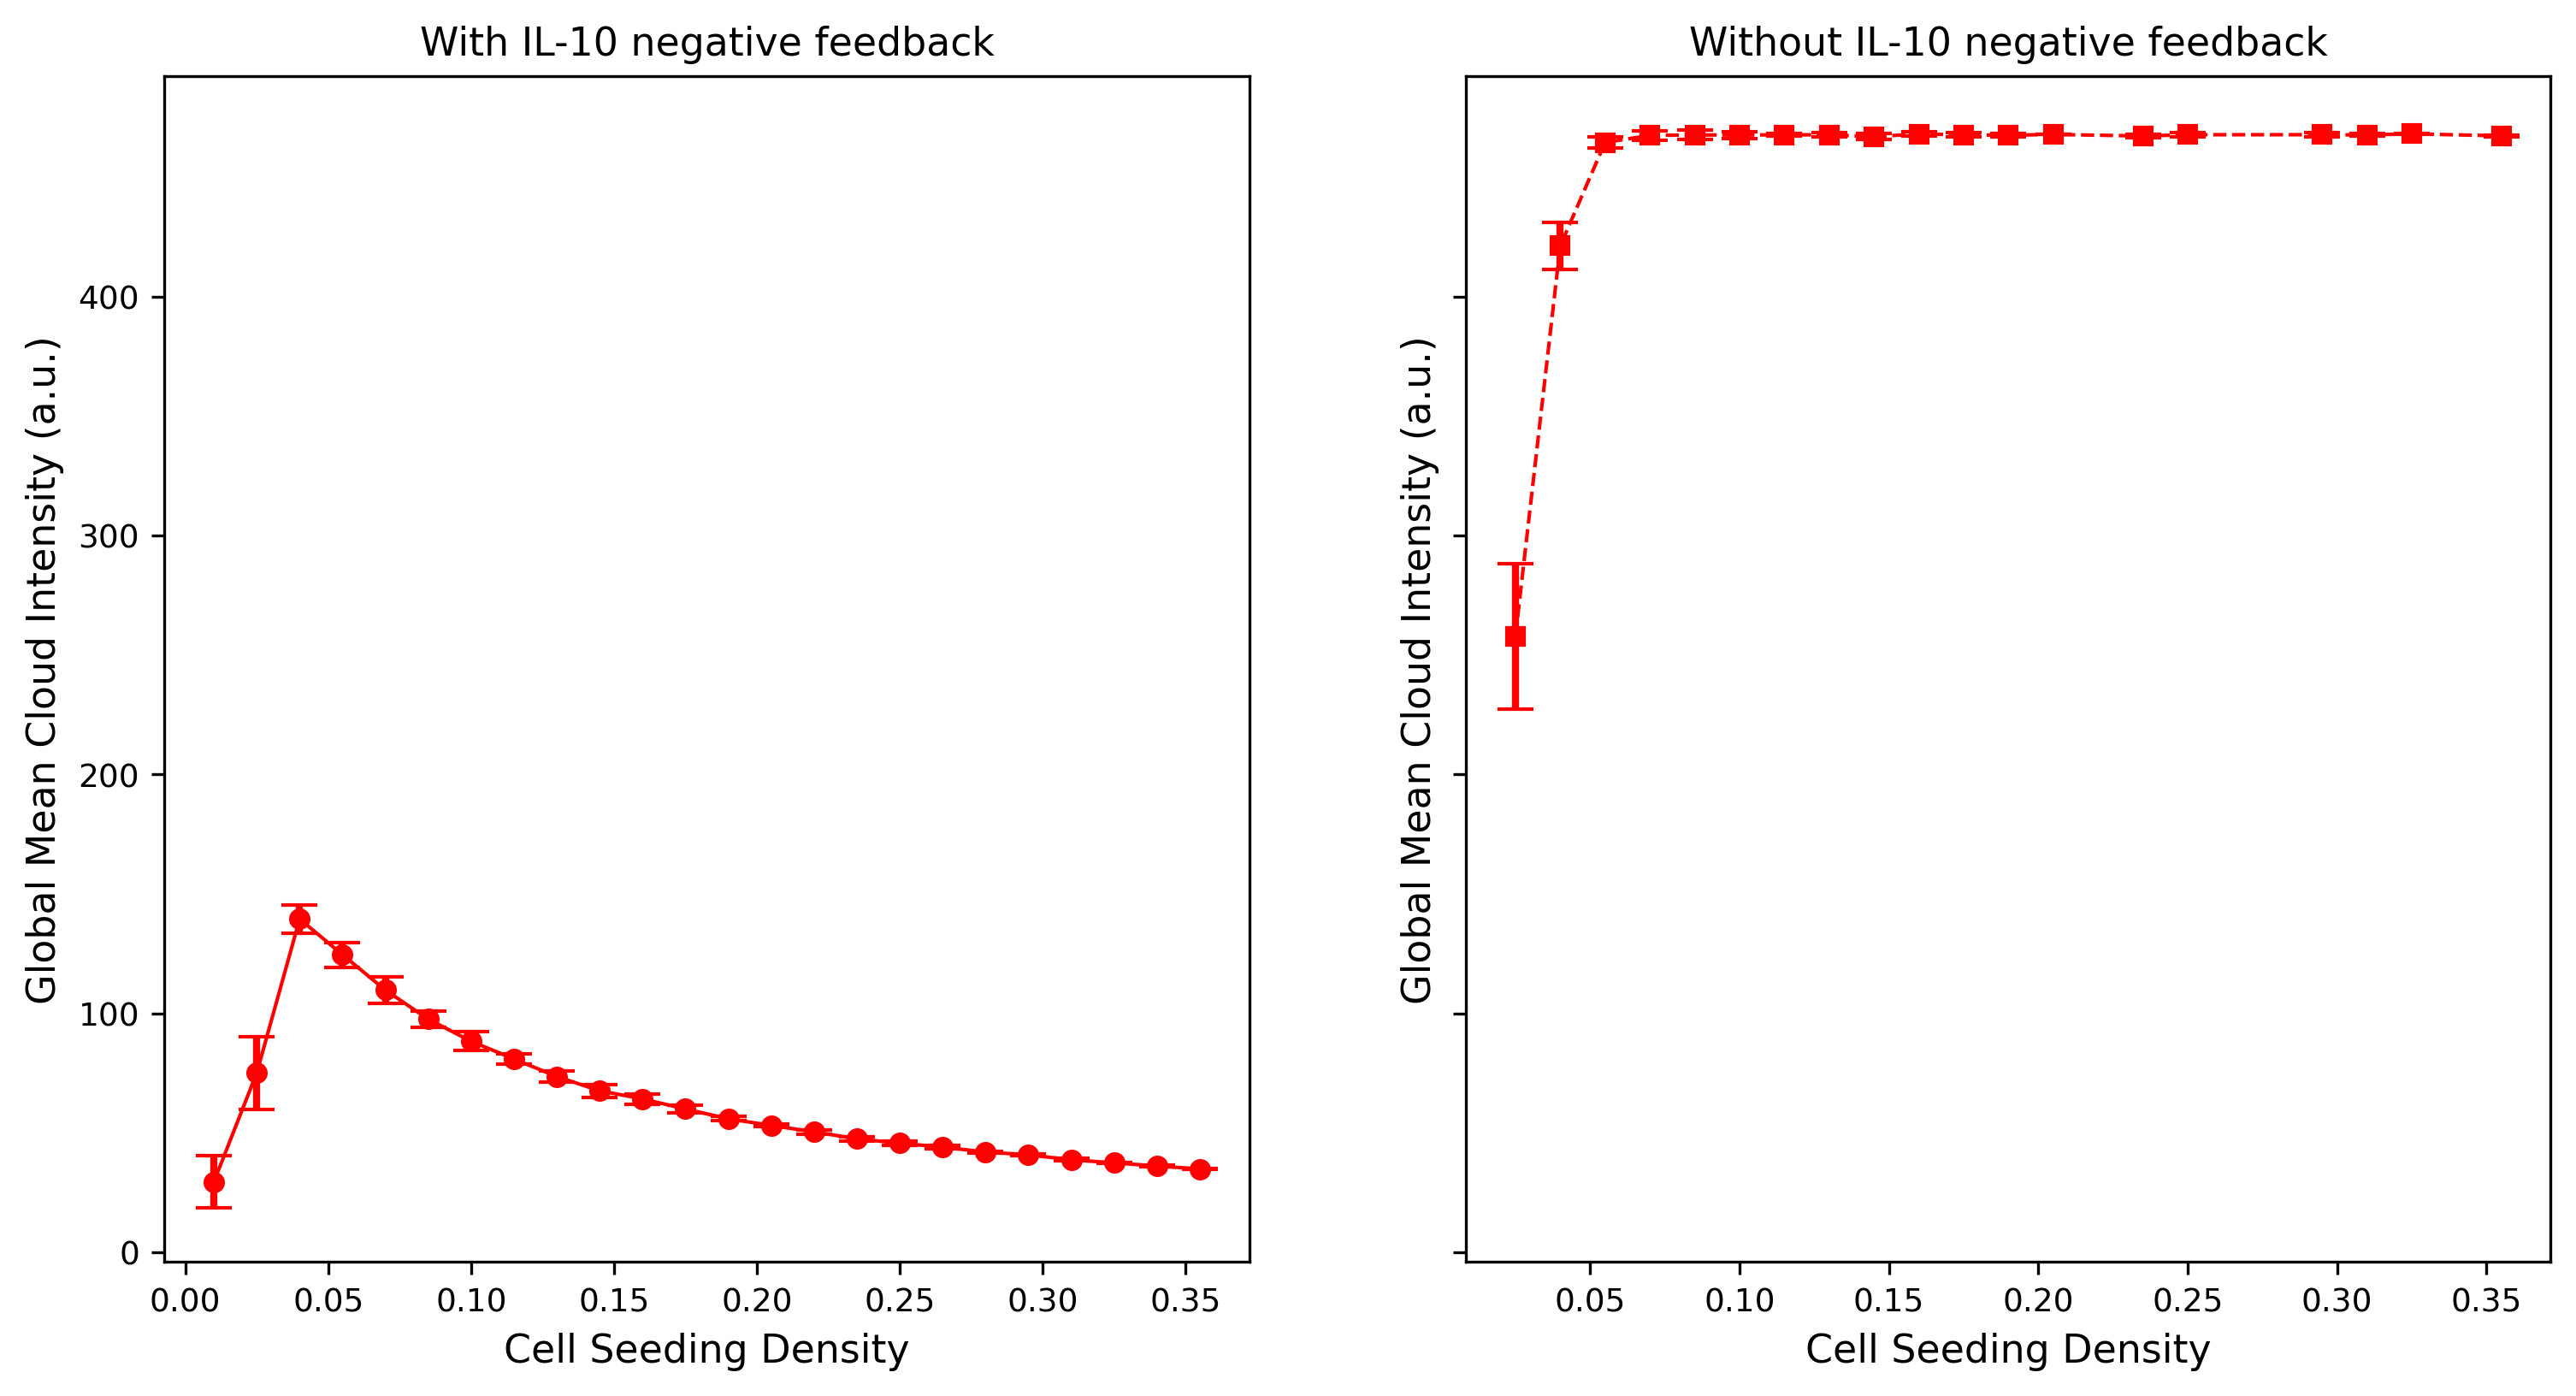

In [82]:
# empty string is for the case with negative feedback.
levels_fig, level_axs = plot.subplots(1, 2, sharey=True, figsize=(12, 6), dpi=300)
clouds_fig, clouds_axs = plot.subplots(1, 2, sharey=True, figsize=(12, 6), dpi=300)
plot_styles = ['ro-', 'rs--']
for main_idx, feedback_str in enumerate(['', 'noneg']):
    plot_all_simulations(feedback_str, level_axs[main_idx], clouds_axs[main_idx], plotstyle=plot_styles[main_idx])
plot.figure(levels_fig)
plot.savefig("levels.png")
plot.figure(clouds_fig)
plot.savefig("clouds.png")